# LAI analysis

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime as dt
import tarfile
import sys
import glob
import scipy.stats as stats
import zipfile
import shutil
import matplotlib as mpl
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.dates as mdates
#from utils import *

#sys.path.insert(1, '../')
from swaplib import *

# Systematic unmixing

In [2]:
import rasterio.mask as riom
import warnings

In [3]:
# https://zenodo.org/records/8281930/files/Readme_for_GIMMS_LAI4g_Product_updated_0825.pdf?download=1
def read_lai_file(f):
    ro = rio.open(f)
    data = ro.read(1)
    data = data.astype("f4")
    data[data==65535.] = np.nan
    data *= 0.001
    return data

In [4]:
# Brandenburg shape
bb = gpd.read_file("../data/bb.geojson").to_crs("epsg:25833")
bbcolumns = bb.columns.tolist()
bbcolumns.remove("NUTS")
bbcolumns.remove("GEN")
bbcolumns.remove("geometry")
bb = bb.drop(columns=bbcolumns)

In [5]:
xmin, ymin, xmax, ymax = bb.total_bounds

### Check CORINE for most important LUTs

@Paul: liegt unter `xchange/maik/paul/lai/data/corine/` -> Pfade anpassen!

In [6]:
# Corine LUT codes
corinecodes = pd.read_csv("/media/x/cosmicsense/data/brandenburg/corine/U2018_CLC2018_V2020_20u1_doc/Info/Legend/Vector/CLC_legend.csv", sep=";")
corinecodes = corinecodes.set_index("CLC_CODE")

In [7]:
# CORINE
clc = {}
# there is a CORINE dataset for these years
frags = ["U2000", "U2006", "U2012", "U2018", "U2018"]
for i, year in enumerate([1990, 2000, 2006, 2012, 2018]):
    tmp = gpd.read_file("/media/x/cosmicsense/data/brandenburg/corine/%s_CLC%d_V2020_20u1.shp/%s_CLC%d_V2020_20u1.shp" % (frags[i], year, frags[i], year)).to_crs("epsg:25833")
    tmp = tmp.rename(columns={"remark":"Remark", "id":"ID", "code_90":"ccode", "code_00":"ccode",
                              "Code_06":"ccode", "Code_12":"ccode", "Code_18":"ccode"})
    tmp = tmp.drop(columns=['OBJECTID', 'Remark', 'Area_Ha', 'ID', 'Shape_Leng', 'Shape_Area'])
    tmp["ccode"] = tmp.ccode.astype(int)
    clc[year] = tmp

In [8]:
corinebb = {}
corinebbperc = {}
for i, year in enumerate([1990, 2000, 2006, 2012, 2018]):
    corinebb[year] = clc[year].overlay(bb, how="intersection")
    corinebb[year]["area"] = corinebb[year].area
    corinebbperc[year] = (100 * corinebb[year][["area","ccode"]].groupby("ccode").sum()/corinebb[year][["area"]].sum()).sort_values("area", ascending=False)
    corinebbperc[year].columns = ["perc"]
    corinebbperc[year]["cumperc"] = corinebbperc[year].cumsum()
    corinebbperc[year] = corinebbperc[year].join(corinecodes[["LABEL3"]])

In [9]:
# Inspect land use percentages and cumulative percentages for Brandenburg
# to make sure we include the most important LUTs
corinebbperc[2018][corinebbperc[2018].cumperc<=99.95]

,perc,cumperc,LABEL3
ccode,,,
211,36.940476,36.940476,Non-irrigated arable land
312,30.306168,67.246644,Coniferous forest
231,14.219495,81.466139,Pastures
112,4.762301,86.228439,Discontinuous urban fabric
311,4.647534,90.875973,Broad-leaved forest
512,1.981322,92.857295,Water bodies
313,1.945988,94.803283,Mixed forest
121,1.125354,95.928637,Industrial or commercial units
324,0.703151,96.631788,Transitional woodland-shrub


In [10]:
corinebbperc[1990][corinebbperc[1990].cumperc<=99.95]

,perc,cumperc,LABEL3
ccode,,,
211,42.779317,42.779317,Non-irrigated arable land
312,28.686855,71.466172,Coniferous forest
231,8.852927,80.319099,Pastures
112,4.343055,84.662153,Discontinuous urban fabric
311,3.797274,88.459427,Broad-leaved forest
313,2.353132,90.812559,Mixed forest
243,2.149662,92.962221,"Land principally occupied by agriculture, with..."
512,1.818286,94.780507,Water bodies
321,1.045056,95.825564,Natural grasslands


In [11]:
# these cover > 99.9 percent of Bbg.
# here we map the CORINE codes to the main LUTs of our study
ccodes = {"pineforest":[312],
          "grassland": [231, 321, 322, 411],
          "otherforest": [141, 311, 313, 324],
          "cropland": [211, 222, 243],
          "other" : [111, 112, 121, 122, 142, 124, # "builtup" 
                     511, 512, # water
                     131, 132, 331, 333] # bare
         }

### Import and preprocess grid from Cao

I created `cao-vector-grid.shp` by vectorising a large portion of the grid from [Cao et al. 2023](https://essd.copernicus.org/articles/15/4877/2023/) over Europe. Here, we intersect it with Brandenburg to actually define our study grid vertices for which we later compile the LUIT fractions.

In [14]:
def ids_from_latlon(x, y, precision=2):
    xstr = np.char.replace((x * 10**precision).astype(int).astype("str"), "-", "W")
    ystr = np.char.replace((y * 10**precision).astype(int).astype("str"), "-", "S")
    return np.char.add(xstr, ystr)

In [15]:
caovgrid = gpd.read_file("../data/cao-vector-grid.shp").to_crs("epsg:25833")
caovgrid = caovgrid.drop(index = caovgrid[caovgrid.VALUE==65535.].index)
#caovgrid["cid"] = caovgrid.index
caovgrid = caovgrid.drop(columns=["VALUE"])
caovgrid["cid"] = ids_from_latlon(caovgrid.centroid.to_crs("epsg:4326").geometry.x.to_numpy(),
                                  caovgrid.centroid.to_crs("epsg:4326").geometry.y.to_numpy())

In [16]:
caovgridbb = caovgrid.overlay(bb, how="intersection")
#caovgridbb = caovgridbb[caovgridbb.area>np.quantile(caovgridbb.area,0.25)]

(5690476.478942125, 5935094.438939898)

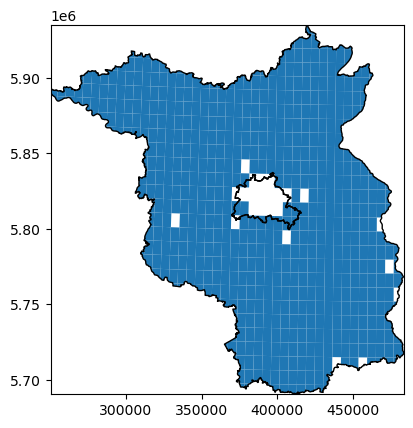

In [20]:
ax = caovgridbb.plot()
bb.plot(ax=ax, facecolor="None")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

In [17]:
# Intersect Cao grid vertices with CORINE for each of the CORINE years
isc = {}
for i, year in enumerate([1990, 2000, 2006, 2012, 2018]):
    isc[year] = caovgridbb.overlay(corinebb[year], how="intersection")
    isc[year]["area"] = isc[year].area

/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 181 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 171 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 170 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom

In [18]:
caovgridbb.to_file("../data/caovgridbb.geojson")

In [19]:
caovgridbb = caovgridbb.set_index("cid")

In [20]:
def get_fraction_in_cao(landuse, vgrid, year):
    vgrid = vgrid.copy()
    isc[year]["code"] = 0
    isc[year].loc[np.in1d(isc[year].ccode, ccodes[landuse]), ["code"]] = 1
    iscgb = isc[year][["cid","code", "area"]].groupby(["cid","code"]).sum()
    area = iscgb.xs(key=1, level=1)
    #area.index = area.index.astype("int")
    vgrid["area_%s_%d" % (landuse, year)] = 0.
    
    vgrid.loc[area.index, "area_%s_%d" % (landuse, year)] = area.area
    
    vgrid["frac_%s_%d" % (landuse, year)] = vgrid["area_%s_%d" % (landuse, year)]/vgrid.area

    return vgrid

In [21]:
for landuse in ccodes.keys():
    for i, year in enumerate([1990, 2000, 2006, 2012, 2018]): 
        caovgridbb = get_fraction_in_cao(landuse, caovgridbb, year)

In [23]:
# Only keep cells which are large enough to be considered in analysis (very subjective)
caovgridbb = caovgridbb[caovgridbb.area>np.quantile(caovgridbb.area,0.25)]

### Read LAI data for remaining mask

- This is the main dataset! I've put it here: `xchange/maik/paul/lai/data/lai/`
- Please copy the data to your environment, then notify me so I can remove it from the share.
- The below paths need to be adjusted.

In [24]:
# Find all files
files = glob.glob("/media/x/cosmicsense/data/lai/*/*.tif", recursive=True)

In [25]:
# Read one file to check spatial constellation 
f = "/media/x/cosmicsense/data/lai/GIMMS_LAI4g_AVHRR_MODIS_consolidated_2001_2010/GIMMS_LAI4g_V1.2_20010101.tif"
tmprio = rio.open(f)
rows, cols = np.indices(tmprio.shape)
ix_pairs = np.column_stack((rows.ravel(), cols.ravel()))
lailons, lailats = tmprio.xy(ix_pairs[:,0],ix_pairs[:,1])
pixelids = ids_from_latlon(lailons, lailats)

In [26]:
fullgridmask = np.zeros(len(pixelids)).astype(bool)
for cid in caovgridbb.index:
    fullgridmask[np.where(pixelids==cid)[0][0]] = True

(52.0, 53.0)

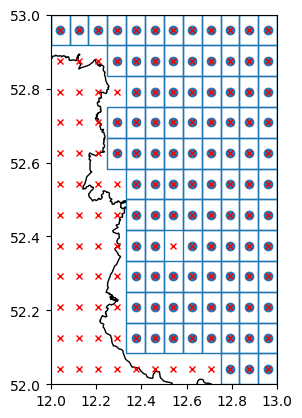

In [27]:
ax = caovgridbb.to_crs("epsg:4326").plot(facecolor="None", edgecolor="tab:blue")
ax.set_aspect("equal")
bb.to_crs("epsg:4326").plot(ax=ax, facecolor="None")
caovgridbb.centroid.to_crs("epsg:4326").plot(ax=ax)
plt.plot(lailons, lailats, "rx", ms=5)
plt.xlim(12,13)
plt.ylim(52, 53)


In [28]:
# Here we read all LAI data and store the time series in lai-extract-from-cao.csv
# This is only rerun if read_anew is True
read_anew = False
results = {}

if read_anew:
    dtimes = []
    #alldata = np.zeros( (len(files), ro.shape[0], ro.shape[1]) )
    
    for file in files:
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        if dtime.day==2:
            # https://zenodo.org/records/8281930/files/Readme_for_GIMMS_LAI4g_Product_updated_0825.pdf?download=1
            # 1 refers to first half of month, 2 to second
            dtime = dt.datetime(dtime.year, dtime.month, 15)
        dtimes.append(dtime)
    
    df = pd.DataFrame(index=dtimes, columns=caovgridbb.index.tolist() )
    df = df.sort_index()

    warnings.filterwarnings("ignore", category=UserWarning)
    #warnings.filterwarnings("ignore", category=RuntimeWarning)
    for file in files:
        print(".", end="")
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        if dtime.day==2:
            # https://zenodo.org/records/8281930/files/Readme_for_GIMMS_LAI4g_Product_updated_0825.pdf?download=1
            # 1 refers to first half of month, 2 to second
            dtime = dt.datetime(dtime.year, dtime.month, 15)
        df.loc[dtime,:] = read_lai_file(file).ravel()[fullgridmask]
    print("")
    warnings.filterwarnings("default", category=UserWarning)
    #warnings.filterwarnings("default", category=RuntimeWarning)
    # fix datetime
    df = df.set_index(df.index)
    df.astype(float).to_csv("../data/lai-extract-from-cao.csv", sep=";", index=True, index_label="datetime", float_format="%.3f")
else:
    df = pd.read_csv("../data/lai-extract-from-cao.csv", sep=";", parse_dates=True, index_col="datetime")

### Unmixing

In [33]:
from scipy.optimize import minimize

In [34]:
def unmix(lais, fractions, laiobs):
    return np.sqrt(np.nanmean(((lais * fractions).sum(axis=1) - laiobs)**2))

In [35]:
def interpol(year1, year2, lut):
    tmp = np.zeros(len(caovgridbb))*np.nan
    for i, cid in enumerate(caovgridbb.index):
        tmp[i] = np.interp(year, [year1, year2], 
                  [caovgridbb.at[cid, "frac_%s_%d" % (lut, year1)], 
                   caovgridbb.at[cid, "frac_%s_%d" % (lut, year2)]])
    return tmp

    
def get_fractions_in_year(lut, year):
    years = [1990, 2000, 2006, 2012, 2018]
    if year <= 1990:
        # extrapolate: nearest neighbour
        return caovgridbb["frac_%s_1990" % lut].to_numpy()
    elif year >= 2018:
        # extrapolate: nearest neighbour
        return caovgridbb["frac_%s_2018" % lut].to_numpy()
    elif (year > 1990) and (year <= 2000):
        return interpol(1990, 2000, lut)
    elif (year > 2000) and (year <= 2006):
        return interpol(2000, 2006, lut)
    elif (year > 2006) and (year <= 2012):
        return interpol(2006, 2012, lut)
    elif (year > 2012) and (year <= 2018):
        return interpol(2012, 2018, lut)
    else:
        print("Something went wrong: no case found.")

fractions = {}
for year in np.arange(1982, 2021):
    print(year, "", end="")
    tmp = pd.DataFrame(index=caovgridbb.index, columns=list(ccodes.keys()))
    for lut in ccodes.keys():
        tmp.loc[:, lut] = get_fractions_in_year(lut, year)
    fractions[year] = tmp

1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 

In [36]:
# selector = ["frac_"+lut for lut in ccodes.keys()]
# fractions = caovgridbb[selector].to_numpy()
#         pines  grass   broadleaves cropland other
initlai = [2.,    2.,     2.,         2.,     0.     ]
bounds = [[1,5], [0,5],  [0,8],      [0,5],  [0, 0.1]]
bblai = pd.DataFrame(index=df.index, columns=list(ccodes.keys()))
errors = pd.DataFrame(index=df.index, columns=["rmse"])
for dtime in df.index:
    myfractions = fractions[dtime.year].to_numpy()
    res = minimize(unmix, initlai, args=(myfractions, df.loc[dtime].to_numpy()), 
                   method="Nelder-Mead", bounds=bounds)
    bblai.loc[dtime,:] = res["x"]
    errors.loc[dtime,:] = res["fun"]

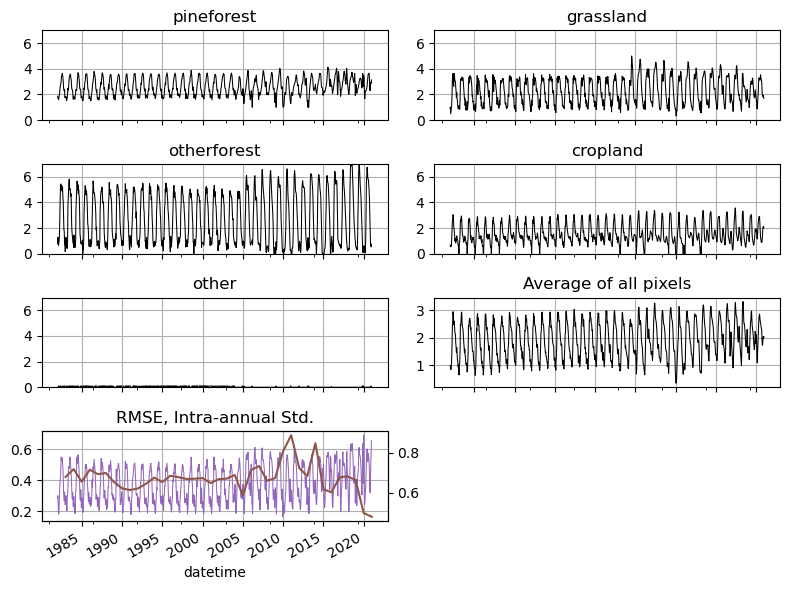

In [37]:
fig, ax = plt.subplots(4,2, figsize=(8,6), sharex=True)
ax = ax.ravel()
for i, lut in enumerate(ccodes.keys()):
    plt.sca(ax[i])
    bblai[[lut]].plot(ax=ax[i], title=lut, legend=False, color="black", lw=0.75)
    plt.ylim(0,7)
    plt.yticks(np.arange(0,8,2))
    plt.grid()

plt.sca(ax[-3])
plt.plot(df.index, df.mean(axis=1), color="black", lw=0.75)
plt.title("Average of all pixels")
plt.grid()

plt.sca(ax[-2])
errors[["rmse"]].plot(ax=ax[-2], title="RMSE, Intra-annual Std.", legend=False, color="tab:purple", lw=0.75)
plt.grid()
ax2=plt.twinx()
tmp = df.mean(axis=1).resample("YE").std()
plt.plot(tmp.index, tmp, color="tab:brown")

ax[-1].axis("off")

plt.tight_layout()


In [38]:
bblaibiweek = bblai.groupby([bblai.index.month, bblai.index.day]).mean()

newindex = []
for i in range(1,13):
    for j in [1,15]:
        newindex.append(dt.datetime(2024, i, j))
bblaibiweek.index = newindex

(19711.0, 20077.0)

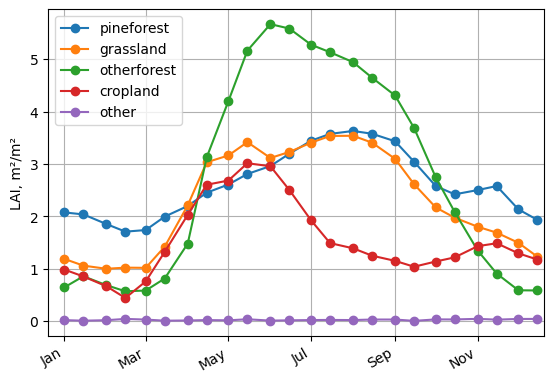

In [47]:
ax = bblaibiweek.plot(marker="o")
plt.sca(ax)
plt.grid()
plt.ylabel("LAI, m²/m²")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.xlim(dt.datetime(2023,12,20), dt.datetime(2024,12,20))

In [43]:
bblaibiweek = bblai.groupby([bblai.index.month, bblai.index.day]).mean()
tmp = bblai.loc["2010-01-01":"2020-12-31"]
bblaibiweek1020 = tmp.groupby([tmp.index.month, tmp.index.day]).mean()
tmp = bblai.loc["1990-01-01":"2000-12-31"]
bblaibiweek9000 = tmp.groupby([tmp.index.month, tmp.index.day]).mean()

newindex = []
for i in range(1,13):
    for j in [1,15]:
        newindex.append(dt.datetime(2024, i, j))
bblaibiweek.index = newindex
bblaibiweek1020.index = newindex
bblaibiweek9000.index = newindex

Text(0, 0.5, 'LAI, m²/m²')

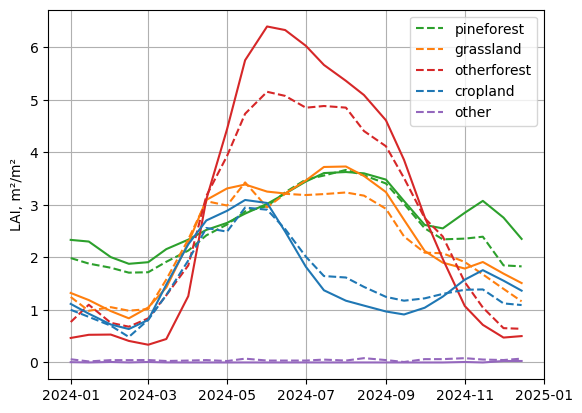

In [50]:
#ax = bblaibiweek.plot(marker="o")
colors = ["tab:green", "tab:orange", "tab:red", "tab:blue", "tab:purple"]
for i, lut in enumerate(ccodes.keys()):
    plt.plot(bblaibiweek9000.index, bblaibiweek9000[lut], color=colors[i], ls="--", label=lut)
    plt.plot(bblaibiweek1020.index, bblaibiweek1020[lut], color=colors[i], ls="-", label="_tmp")
plt.grid()
plt.legend()
plt.ylabel("LAI, m²/m²")

In [42]:
def get_linear_trend(df, var, start, end, verbose=True):
    tmptrend = df.loc[start:end]
    tmptrend.loc[tmptrend.index,["delta"]] = [(item - tmptrend.index[0]).total_seconds() for item in tmptrend.index]
    slope, intercept, r, p, se = scipy.stats.linregress(tmptrend.delta.to_numpy(), tmptrend[var].to_numpy())
    ypred = intercept + slope*tmptrend.delta
    pstr = get_sign_level(p)
    slope *= 365.25*86400*10
    se *= 365.25*86400*10
    if verbose:
        print("slope=%.2f dec⁻¹ +/- %.2f dec⁻¹, %s (p=%.3f)" % (slope, se, pstr, p))
    return slope, intercept, r, p, se, ypred, pstr
for lut in ccodes.keys():
    print(lut)
    _ = get_linear_trend(bblai.astype(float), lut, "1982-01-01", "2020-12-31")
print("all")
tmp = df.mean(axis=1)
tmp
_ = get_linear_trend(pd.DataFrame(df.mean(axis=1)), 0, "1982-01-01", "2020-12-31")

pineforest
slope=0.10 dec⁻¹ +/- 0.02 dec⁻¹, *** (p=0.000)
grassland
slope=0.09 dec⁻¹ +/- 0.03 dec⁻¹, *** (p=0.002)
otherforest
slope=0.06 dec⁻¹ +/- 0.06 dec⁻¹,     (p=0.323)
cropland
slope=0.06 dec⁻¹ +/- 0.02 dec⁻¹, **  (p=0.010)
other
slope=-0.01 dec⁻¹ +/- 0.00 dec⁻¹, *** (p=0.000)
all
slope=0.09 dec⁻¹ +/- 0.02 dec⁻¹, *** (p=0.000)
